# 🌾 Smart Agriculture Monitoring — POC Data & IA v2.0

> **Données réelles** issues de l'API [Open-Meteo](https://open-meteo.com) — sans clé API.

**Objectif :** Surveiller les cultures agricoles, détecter les risques de sécheresse et améliorer le rendement grâce à la Data et au Machine Learning.

| Étape | Description |
|-------|-------------|
| 0 | Installation & Imports |
| 1 | Collecte données réelles (Open-Meteo API) |
| 2 | Exploration & Visualisation |
| 3 | Nettoyage & Qualité |
| 4 | Feature Engineering |
| 5 | Modélisation ML (comparaison 3 modèles) |
| 6 | Évaluation & Interprétabilité |
| 7 | Système d'alertes temps réel |

---

## 📦 0. Installation & Imports

In [21]:
# !pip install pandas numpy scikit-learn matplotlib seaborn requests joblib

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.dates as mdates
import seaborn as sns
import requests
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay,
    precision_score, recall_score, f1_score, accuracy_score
)
import joblib

# Style global
plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.family'] = 'DejaVu Sans'
PALETTE = {'0': '#1D9E75', '1': '#D85A30'}
print('✅ Imports OK')

✅ Imports OK


## 🌍 1. Collecte des données réelles — Open-Meteo API

In [22]:
# ── Configuration des villes agricoles africaines
CITIES = {
    'Dakar, Sénégal':          (14.69, -17.44),
    'Bamako, Mali':             (12.65,  -8.00),
    'Abidjan, Côte d\'Ivoire':  ( 5.35,  -4.00),
    'Nairobi, Kenya':           (-1.29,  36.82),
    'Addis-Abeba, Éthiopie':    ( 9.03,  38.74),
}

# ── Choix de la ville (modifier ici)
CITY_NAME = 'Dakar, Sénégal'
LAT, LON  = CITIES[CITY_NAME]

print(f'📍 Région sélectionnée : {CITY_NAME} ({LAT}, {LON})')

📍 Région sélectionnée : Dakar, Sénégal (14.69, -17.44)


In [23]:
def fetch_weather_data(lat: float, lon: float,
                       start: str = '2020-01-01',
                       end: str   = '2026-03-31') -> pd.DataFrame:
    """
    Récupère les données météo historiques via l'API Open-Meteo.
    Aucune clé API requise — données sous licence CC BY 4.0.
    """
    url = 'https://archive-api.open-meteo.com/v1/archive'
    params = {
        'latitude':  lat,
        'longitude': lon,
        'start_date': start,
        'end_date':   end,
        'daily': [
            'temperature_2m_max',
            'temperature_2m_min',
            'precipitation_sum',
            'relative_humidity_2m_max',
            'relative_humidity_2m_min',
            'soil_moisture_0_to_7cm_mean',
            'et0_fao_evapotranspiration',
            'wind_speed_10m_max',
        ],
        'timezone': 'auto',
    }

    print(f'📡 Appel API Open-Meteo pour ({lat}, {lon}) de {start} à {end}...')
    r = requests.get(url, params=params, timeout=20)
    r.raise_for_status()

    raw = r.json()['daily']
    df = pd.DataFrame(raw).rename(columns={
        'time':                         'date',
        'temperature_2m_max':           'temp_max',
        'temperature_2m_min':           'temp_min',
        'precipitation_sum':            'rainfall',
        'relative_humidity_2m_max':     'humidity_max',
        'relative_humidity_2m_min':     'humidity_min',
        'soil_moisture_0_to_7cm_mean':  'soil_moisture_raw',
        'et0_fao_evapotranspiration':   'evapotranspiration',
        'wind_speed_10m_max':           'wind_speed',
    })

    df['date'] = pd.to_datetime(df['date'])

    # Créer les variables principales
    df['temperature']  = ((df['temp_max'] + df['temp_min']) / 2).round(2)
    df['humidity']     = ((df['humidity_max'] + df['humidity_min']) / 2).round(2)
    # Convertir soil_moisture volumétrique (m³/m³) → pourcentage lisible
    df['soil_moisture'] = (df['soil_moisture_raw'] * 100).clip(0, 60).round(2)

    df = df.dropna(subset=['temperature', 'humidity', 'rainfall', 'soil_moisture'])
    df = df.reset_index(drop=True)

    print(f'✅ {len(df)} jours chargés | Colonnes : {list(df.columns)}')
    return df


df_raw = fetch_weather_data(LAT, LON)
df_raw.head()

📡 Appel API Open-Meteo pour (14.69, -17.44) de 2020-01-01 à 2026-03-31...
✅ 2282 jours chargés | Colonnes : ['date', 'temp_max', 'temp_min', 'rainfall', 'humidity_max', 'humidity_min', 'soil_moisture_raw', 'evapotranspiration', 'wind_speed', 'temperature', 'humidity', 'soil_moisture']


,date,temp_max,temp_min,rainfall,humidity_max,humidity_min,soil_moisture_raw,evapotranspiration,wind_speed,temperature,humidity,soil_moisture
0,2020-01-01,30.8,21.8,0.0,53,14,0.041,7.93,26.2,26.3,33.5,4.1
1,2020-01-02,28.2,20.2,0.0,55,14,0.041,7.05,24.2,24.2,34.5,4.1
2,2020-01-03,29.1,21.5,0.0,43,15,0.041,6.82,21.9,25.3,29.0,4.1
3,2020-01-04,27.9,20.5,0.0,60,16,0.041,7.06,24.3,24.2,38.0,4.1
4,2020-01-05,26.7,18.5,0.0,64,17,0.040,6.65,28.0,22.6,40.5,4.0


In [24]:
# ── Labellisation du risque de sécheresse (règles agronomiques)
df_raw['risk'] = (
    ((df_raw['temperature'] > 33)    & (df_raw['humidity'] < 45))       |
    ((df_raw['soil_moisture'] < 12)  & (df_raw['rainfall'] < 2))        |
    ((df_raw['temperature'] > 38)    & (df_raw['soil_moisture'] < 20))
).astype(int)

# Dataset de travail (variables principales)
MAIN_COLS = ['date', 'temperature', 'humidity', 'rainfall', 'soil_moisture',
             'evapotranspiration', 'wind_speed', 'risk']
df = df_raw[MAIN_COLS].copy()

print(f'Shape final : {df.shape}')
print(f'Période     : {df["date"].min().date()} → {df["date"].max().date()}')
print(f'Jours à risque : {df["risk"].sum()} ({df["risk"].mean():.1%})')
df.tail()

Shape final : (2282, 8)
Période     : 2020-01-01 → 2026-03-31
Jours à risque : 1880 (82.4%)


,date,temperature,humidity,rainfall,soil_moisture,evapotranspiration,wind_speed,risk
2277,2026-03-27,20.95,81.0,0.0,4.0,3.97,20.2,1
2278,2026-03-28,22.10,76.0,0.0,4.0,4.38,17.9,1
2279,2026-03-29,23.30,69.5,0.0,4.0,5.02,18.5,1
2280,2026-03-30,24.40,64.5,0.0,4.0,5.34,21.7,1
2281,2026-03-31,24.80,63.0,0.0,4.0,5.60,23.5,1


## 📊 2. Exploration & Visualisation

In [25]:
print('=== Statistiques descriptives ===')
display(df.drop(columns='date').describe().round(2))

=== Statistiques descriptives ===


,temperature,humidity,rainfall,soil_moisture,evapotranspiration,wind_speed,risk
count,2282.00,2282.00,2282.00,2282.00,2282.00,2282.00,2282.00
mean,25.51,68.65,0.93,6.67,4.89,22.06,0.82
std,2.72,13.53,3.94,6.17,1.09,5.49,0.38
min,18.90,18.50,0.00,1.40,1.50,5.70,0.00
25%,23.25,60.50,0.00,3.60,4.27,17.90,1.00
50%,26.10,73.00,0.00,4.20,4.74,21.90,1.00
75%,27.75,79.00,0.00,5.80,5.38,25.70,1.00
max,33.30,89.50,76.90,34.90,10.59,45.80,1.00


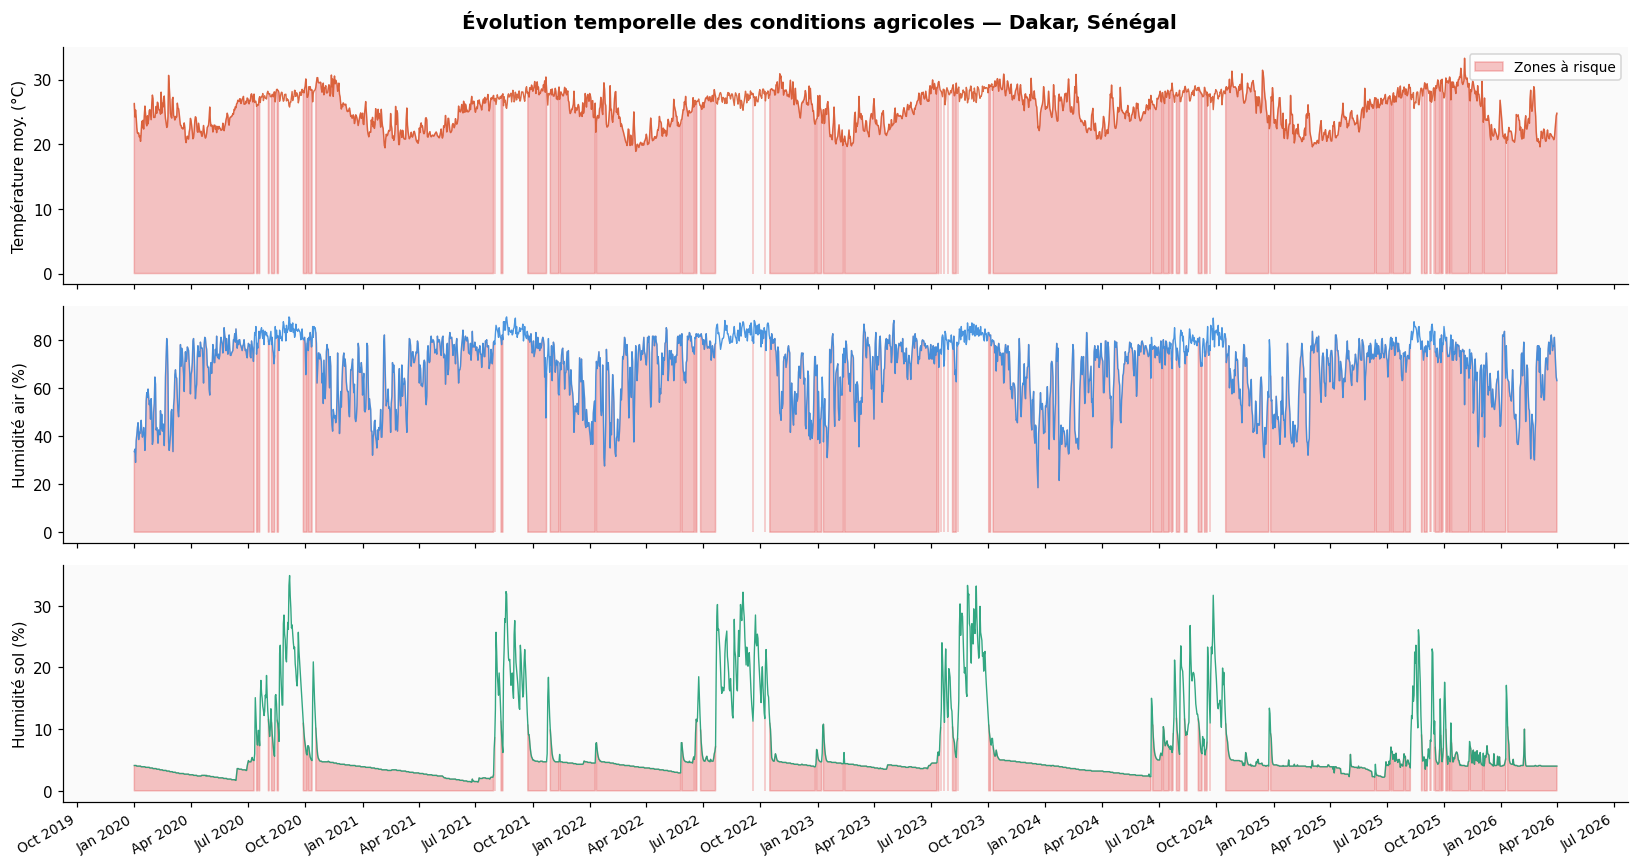

In [26]:
# ── Évolution temporelle avec zones à risque
fig, axes = plt.subplots(3, 1, figsize=(15, 8), sharex=True)
fig.suptitle(f'Évolution temporelle des conditions agricoles — {CITY_NAME}',
             fontsize=13, fontweight='bold')

vars_plot = [
    ('temperature',  'Température moy. (°C)', '#D85A30'),
    ('humidity',     'Humidité air (%)',       '#378ADD'),
    ('soil_moisture','Humidité sol (%)',       '#1D9E75'),
]

for ax, (col, label, color) in zip(axes, vars_plot):
    ax.plot(df['date'], df[col], color=color, linewidth=0.9, alpha=0.9)
    ax.fill_between(df['date'], df[col],
                    where=df['risk'] == 1,
                    color='#e53e3e', alpha=0.3, label='Zones à risque')
    ax.set_ylabel(label, fontsize=10)
    ax.spines[['top', 'right']].set_visible(False)
    ax.set_facecolor('#fafafa')

axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
axes[-1].xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.xticks(rotation=30, ha='right', fontsize=9)
axes[0].legend(fontsize=9)
plt.tight_layout()
plt.savefig('timeseries.png', bbox_inches='tight', dpi=120)
plt.show()

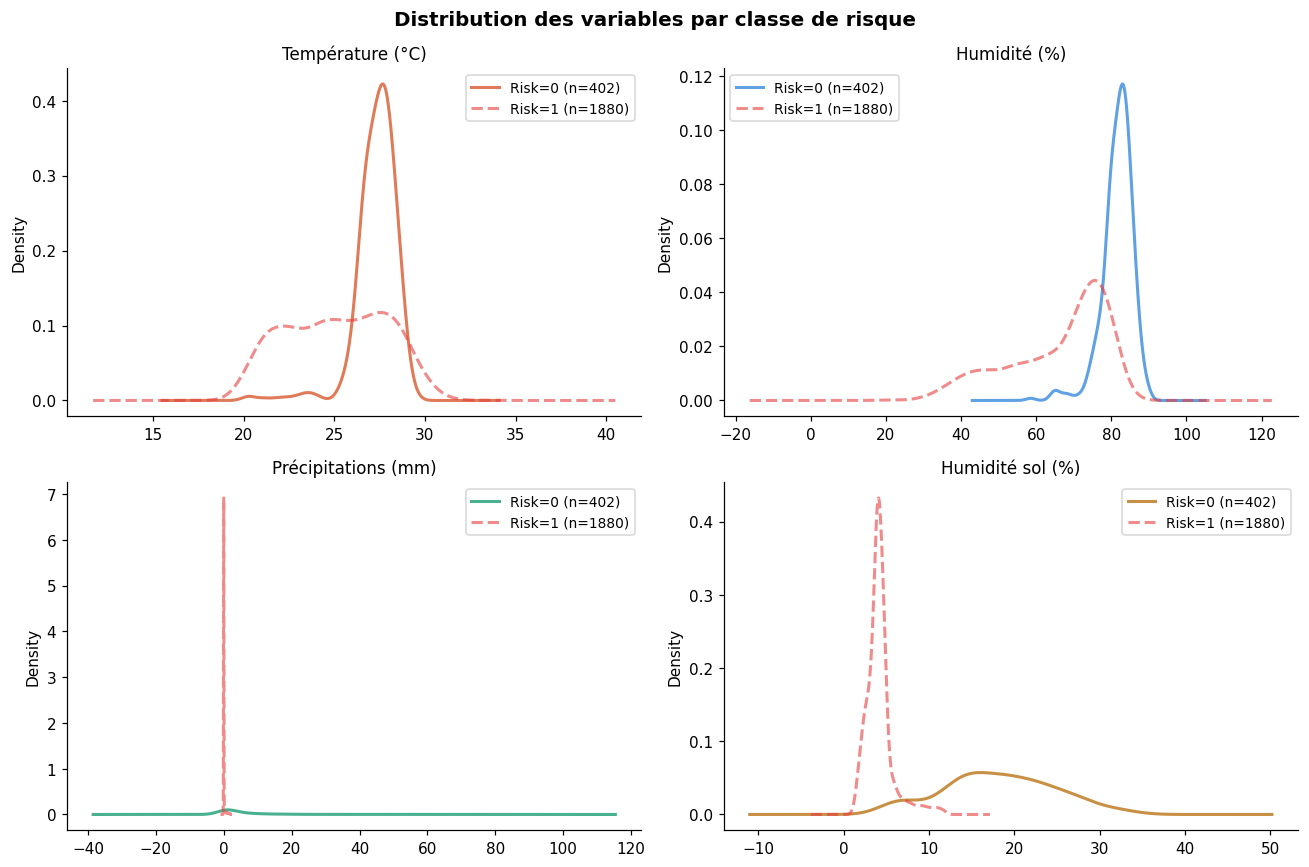

In [27]:
# ── Distributions par classe de risque
features_viz = ['temperature', 'humidity', 'rainfall', 'soil_moisture']
labels_viz   = ['Température (°C)', 'Humidité (%)', 'Précipitations (mm)', 'Humidité sol (%)']
colors_viz   = ['#D85A30', '#378ADD', '#1D9E75', '#BA7517']

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('Distribution des variables par classe de risque', fontsize=13, fontweight='bold')

for ax, feat, label, color in zip(axes.flat, features_viz, labels_viz, colors_viz):
    for cls, ls, alpha in [(0, '-', 0.8), (1, '--', 0.6)]:
        subset = df[df['risk'] == cls][feat].dropna()
        subset.plot.kde(ax=ax,
                        label=f'Risk={cls} (n={len(subset)})',
                        color=color if cls == 0 else '#e53e3e',
                        alpha=alpha, linestyle=ls, linewidth=2)
    ax.set_title(label, fontsize=11)
    ax.legend(fontsize=9)
    ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('distributions.png', bbox_inches='tight', dpi=120)
plt.show()

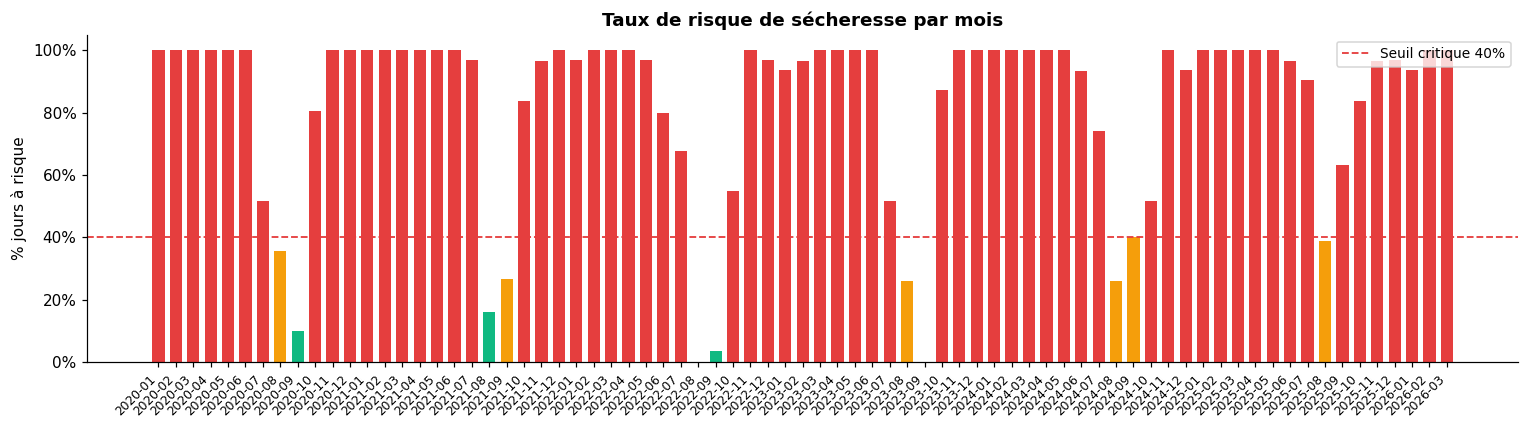

In [28]:
# ── Répartition mensuelle du risque
df['month'] = df['date'].dt.month
df['year']  = df['date'].dt.year

monthly = df.groupby(['year', 'month'])['risk'].mean().reset_index()
monthly['label'] = monthly['year'].astype(str) + '-' + monthly['month'].astype(str).str.zfill(2)

fig, ax = plt.subplots(figsize=(14, 4))
bar_colors = ['#e53e3e' if v > 0.4 else '#f59e0b' if v > 0.2 else '#10b981'
              for v in monthly['risk']]
ax.bar(monthly['label'], monthly['risk'], color=bar_colors, width=0.7)
ax.axhline(0.4, color='#e53e3e', linewidth=1.2, linestyle='--', label='Seuil critique 40%')
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.set_title('Taux de risque de sécheresse par mois', fontweight='bold')
ax.set_ylabel('% jours à risque')
ax.spines[['top', 'right']].set_visible(False)
ax.legend(fontsize=9)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.tight_layout()
plt.show()

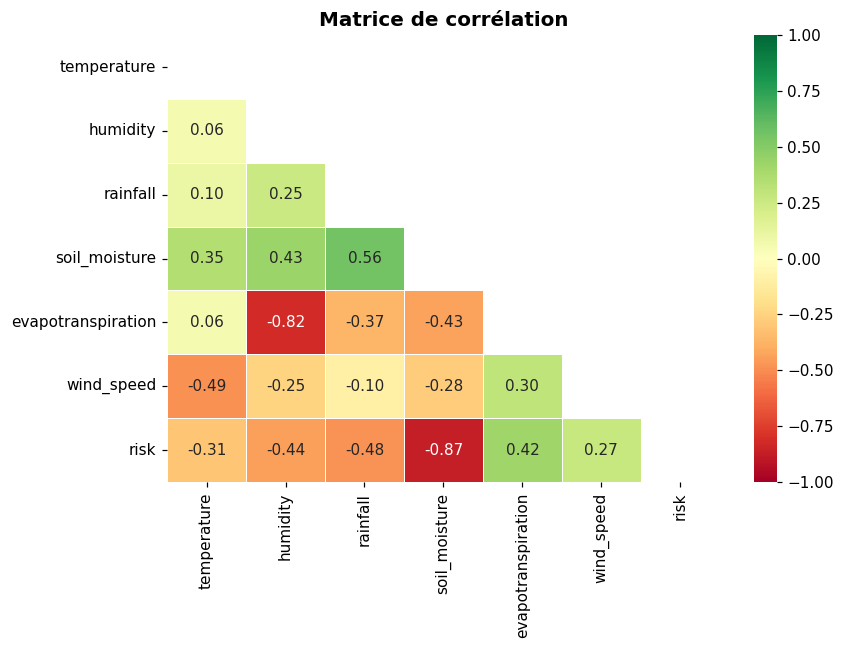

In [29]:
# ── Matrice de corrélation
numeric_df = df[['temperature', 'humidity', 'rainfall', 'soil_moisture',
                  'evapotranspiration', 'wind_speed', 'risk']]

fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(numeric_df.corr(), dtype=bool))
sns.heatmap(numeric_df.corr().round(2), annot=True, fmt='.2f',
            cmap='RdYlGn', mask=mask, ax=ax, linewidths=0.5, vmin=-1, vmax=1)
ax.set_title('Matrice de corrélation', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 🧹 3. Nettoyage & Vérification de la qualité

In [30]:
print('─' * 50)
print('Valeurs manquantes :')
print(df.isnull().sum())
print(f'\nDoublons : {df.duplicated().sum()}')
print(f'Période couverte : {df["date"].min().date()} → {df["date"].max().date()}')
print(f'Continuité temporelle : {(df["date"].diff().dropna() == pd.Timedelta("1D")).all()}')

# Vérification outliers (Z-score > 3)
print('\nOutliers potentiels (|Z| > 3) :')
check_cols = ['temperature', 'humidity', 'rainfall', 'soil_moisture']
for col in check_cols:
    z = np.abs((df[col] - df[col].mean()) / df[col].std())
    n_out = (z > 3).sum()
    print(f'  {col:20s}: {n_out} outlier(s)')

──────────────────────────────────────────────────
Valeurs manquantes :
date                  0
temperature           0
humidity              0
rainfall              0
soil_moisture         0
evapotranspiration    0
wind_speed            0
risk                  0
month                 0
year                  0
dtype: int64

Doublons : 0
Période couverte : 2020-01-01 → 2026-03-31
Continuité temporelle : True

Outliers potentiels (|Z| > 3) :
  temperature         : 0 outlier(s)
  humidity            : 4 outlier(s)
  rainfall            : 46 outlier(s)
  soil_moisture       : 64 outlier(s)


## ⚙️ 4. Feature Engineering

In [31]:
df_fe = df.copy()

# Feature 1 — ratio stress évaporatoire
df_fe['temp_humidity_ratio'] = (df_fe['temperature'] / (df_fe['humidity'] + 1)).round(4)

# Feature 2 — indice de stress hydrique
df_fe['hydric_stress_index'] = ((df_fe['temperature'] - 25) / (df_fe['soil_moisture'] + 1)).round(4)

# Feature 3 — log précipitations (réduction asymétrie)
df_fe['log_rainfall'] = np.log1p(df_fe['rainfall']).round(4)

# Feature 4 — rolling mean température 7 jours (tendance)
df_fe['temp_rolling_7d'] = df_fe['temperature'].rolling(7, min_periods=1).mean().round(2)

# Feature 5 — déficit hydrique (évapotranspiration - pluie)
df_fe['water_deficit'] = (df_fe['evapotranspiration'] - df_fe['rainfall']).round(2)

new_features = ['temp_humidity_ratio', 'hydric_stress_index', 'log_rainfall',
                'temp_rolling_7d', 'water_deficit']

print('Nouvelles features créées :')
display(df_fe[new_features].describe().round(3))

Nouvelles features créées :


,temp_humidity_ratio,hydric_stress_index,log_rainfall,temp_rolling_7d,water_deficit
count,2282.000,2282.000,2282.000,2282.000,2282.000
mean,0.385,-0.001,0.243,25.510,3.956
std,0.112,0.514,0.639,2.551,4.461
min,0.232,-1.284,0.000,19.570,-73.770
25%,0.320,-0.375,0.000,23.342,4.123
50%,0.351,0.103,0.000,26.065,4.710
75%,0.411,0.367,0.000,27.638,5.370
max,1.233,1.628,4.355,30.580,10.590


## 🤖 5. Modélisation ML

In [32]:
# ── Préparation train/test
FEATURE_COLS = [
    'temperature', 'humidity', 'rainfall', 'soil_moisture',
    'temp_humidity_ratio', 'hydric_stress_index', 'log_rainfall',
    'temp_rolling_7d', 'water_deficit'
]

df_fe_clean = df_fe.dropna(subset=FEATURE_COLS + ['risk'])

X = df_fe_clean[FEATURE_COLS]
y = df_fe_clean['risk']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f'Train : {X_train.shape[0]} samples | Test : {X_test.shape[0]} samples')
print(f'Ratio risque train : {y_train.mean():.1%} | test : {y_test.mean():.1%}')

Train : 1825 samples | Test : 457 samples
Ratio risque train : 82.4% | test : 82.3%


In [33]:
# ── Comparaison de 3 modèles (cross-validation)
models = {
    'Logistic Regression': LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=150, class_weight='balanced',
                                                   max_depth=12, random_state=42, n_jobs=-1),
    'Gradient Boosting':   GradientBoostingClassifier(n_estimators=150, random_state=42),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = {}

print('Comparaison des modèles (ROC-AUC, 5-fold CV) :')
print('─' * 55)
for name, model in models.items():
    scores = cross_val_score(model, X_train_sc, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)
    results[name] = {'mean': scores.mean(), 'std': scores.std()}
    print(f'{name:25s} → {scores.mean():.4f} ± {scores.std():.4f}')

best_name = max(results, key=lambda k: results[k]['mean'])
print(f'\n🏆 Meilleur modèle : {best_name}')

Comparaison des modèles (ROC-AUC, 5-fold CV) :
───────────────────────────────────────────────────────
Logistic Regression       → 0.9985 ± 0.0007
Random Forest             → 1.0000 ± 0.0000
Gradient Boosting         → 0.9994 ± 0.0012

🏆 Meilleur modèle : Random Forest


In [34]:
# ── Entraînement du modèle final
rf = RandomForestClassifier(
    n_estimators=150, class_weight='balanced',
    max_depth=12, random_state=42, n_jobs=-1
)
rf.fit(X_train_sc, y_train)

# Sauvegarde
joblib.dump(rf,     'model.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(FEATURE_COLS, 'feature_cols.pkl')
print('✅ Modèle, scaler et feature_cols sauvegardés.')

✅ Modèle, scaler et feature_cols sauvegardés.


## 📈 6. Évaluation & Interprétabilité

In [35]:
y_pred      = rf.predict(X_test_sc)
y_pred_prob = rf.predict_proba(X_test_sc)[:, 1]

print('=' * 55)
print('           RAPPORT DE CLASSIFICATION')
print('=' * 55)
print(classification_report(y_test, y_pred,
                             target_names=['Pas de risque', 'Risque sécheresse'],
                             zero_division=0))
print(f'ROC-AUC Score : {roc_auc_score(y_test, y_pred_prob):.4f}')

           RAPPORT DE CLASSIFICATION
                   precision    recall  f1-score   support

    Pas de risque       1.00      0.99      0.99        81
Risque sécheresse       1.00      1.00      1.00       376

         accuracy                           1.00       457
        macro avg       1.00      0.99      1.00       457
     weighted avg       1.00      1.00      1.00       457

ROC-AUC Score : 0.9999


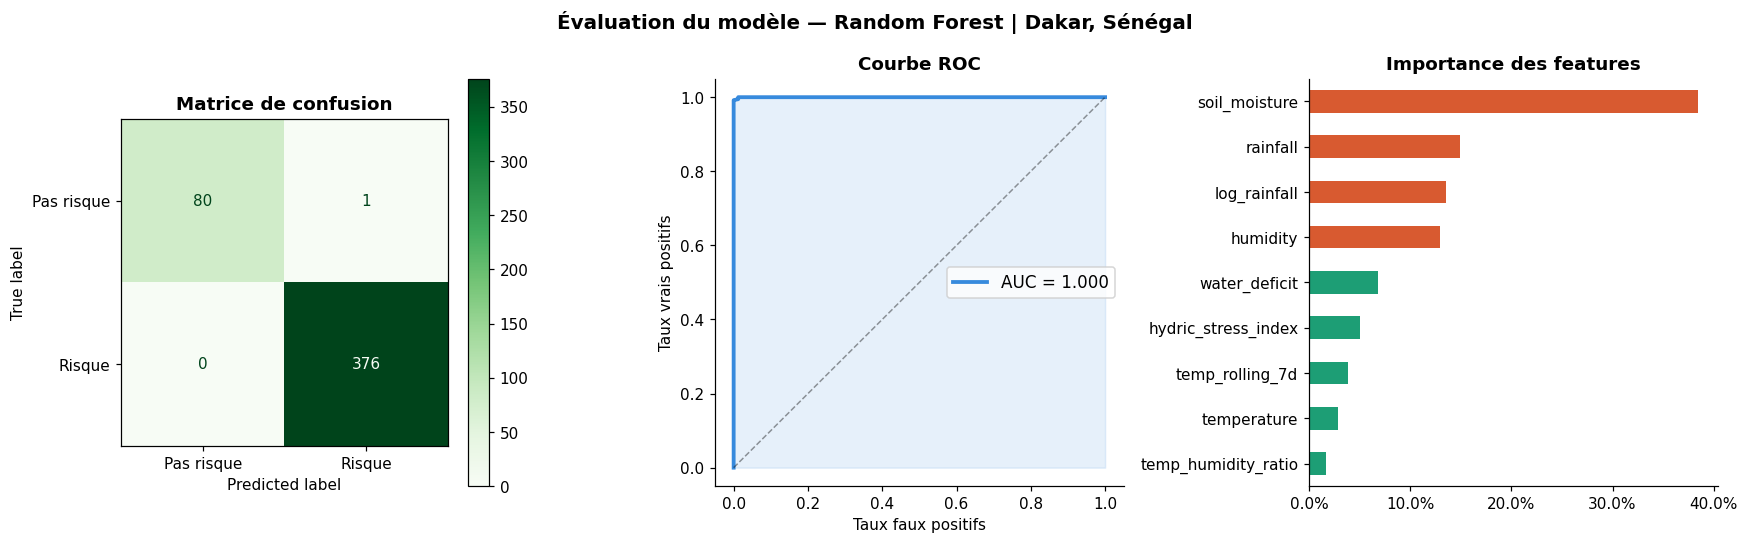

In [36]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
auc_val = roc_auc_score(y_test, y_pred_prob)

# 1. Matrice de confusion
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=['Pas risque', 'Risque'],
    cmap='Greens', ax=axes[0]
)
axes[0].set_title('Matrice de confusion', fontweight='bold')

# 2. Courbe ROC
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
axes[1].plot(fpr, tpr, color='#378ADD', linewidth=2.5, label=f'AUC = {auc_val:.3f}')
axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.4, linewidth=1)
axes[1].fill_between(fpr, tpr, alpha=0.12, color='#378ADD')
axes[1].set_xlabel('Taux faux positifs')
axes[1].set_ylabel('Taux vrais positifs')
axes[1].set_title('Courbe ROC', fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].spines[['top', 'right']].set_visible(False)

# 3. Importance des features
fi = pd.Series(rf.feature_importances_, index=FEATURE_COLS).sort_values()
colors_fi = ['#1D9E75' if v < 0.12 else '#D85A30' for v in fi.values]
fi.plot.barh(ax=axes[2], color=colors_fi)
axes[2].set_title('Importance des features', fontweight='bold')
axes[2].spines[['top', 'right']].set_visible(False)
axes[2].xaxis.set_major_formatter(mticker.PercentFormatter(1.0))

fig.suptitle(f'Évaluation du modèle — Random Forest | {CITY_NAME}',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('evaluation.png', bbox_inches='tight', dpi=120)
plt.show()

## 🚨 7. Système d'alertes

In [37]:
def generate_alerts(obs: dict) -> list[dict]:
    """Génère des alertes agronomiques à partir d'une observation terrain."""
    alerts = []
    if obs['temperature'] > 38:
        alerts.append({'level': 'CRITIQUE', 'icon': '🔴',
                        'message': f"Température critique {obs['temperature']:.1f}°C — stress thermique sévère"})
    elif obs['temperature'] > 33:
        alerts.append({'level': 'ALERTE',   'icon': '🟠',
                        'message': f"Température élevée {obs['temperature']:.1f}°C — surveiller l'évapotranspiration"})

    if obs['soil_moisture'] < 12:
        alerts.append({'level': 'CRITIQUE', 'icon': '🔴',
                        'message': f"Humidité sol critique {obs['soil_moisture']:.1f}% — irrigation immédiate"})
    elif obs['soil_moisture'] < 22:
        alerts.append({'level': 'ALERTE',   'icon': '🟠',
                        'message': f"Humidité sol faible {obs['soil_moisture']:.1f}% — irrigation préventive"})

    if obs['rainfall'] < 2:
        alerts.append({'level': 'ALERTE',   'icon': '🟠',
                        'message': f"Précipitations insuffisantes {obs['rainfall']:.1f}mm/j"})

    if obs['humidity'] < 30:
        alerts.append({'level': 'INFO',     'icon': '🔵',
                        'message': f"Humidité air basse {obs['humidity']:.1f}% — évaporation accélérée"})

    if not alerts:
        alerts.append({'level': 'OK', 'icon': '🟢',
                        'message': 'Toutes les conditions sont dans les normes agronomiques.'})
    return alerts


def predict_and_alert(observation: dict, model, scaler, feature_cols: list):
    """Pipeline complet : feature engineering + prédiction + alertes."""
    obs = observation.copy()
    obs['temp_humidity_ratio'] = obs['temperature'] / (obs['humidity'] + 1)
    obs['hydric_stress_index']  = (obs['temperature'] - 25) / (obs['soil_moisture'] + 1)
    obs['log_rainfall']         = np.log1p(obs['rainfall'])
    obs.setdefault('temp_rolling_7d', obs['temperature'])  # valeur par défaut
    obs.setdefault('water_deficit',   obs.get('evapotranspiration', 5) - obs['rainfall'])

    X_obs    = np.array([[obs[f] for f in feature_cols]])
    X_obs_sc = scaler.transform(X_obs)

    proba = model.predict_proba(X_obs_sc)[0, 1]
    pred  = int(proba >= 0.5)

    print(f'\n📍 Observation : {observation}')
    print(f'\n🤖 Prédiction ML')
    print(f'   Probabilité de sécheresse : {proba:.1%}')
    print(f'   Résultat : {"⚠️  RISQUE DÉTECTÉ" if pred else "✅  PAS DE RISQUE"}')
    print(f'\n🚨 Alertes agronomiques')
    for a in generate_alerts(observation):
        print(f'   {a["icon"]} [{a["level"]:8s}] {a["message"]}')


# ── Test sur 3 scénarios
scenarios = [
    {'temperature': 40.0, 'humidity': 22.0, 'rainfall': 0.5, 'soil_moisture': 9.0,
     'evapotranspiration': 7.0, 'wind_speed': 15.0},   # sécheresse
    {'temperature': 26.0, 'humidity': 72.0, 'rainfall': 8.0, 'soil_moisture': 35.0,
     'evapotranspiration': 3.5, 'wind_speed': 8.0},    # normal
    {'temperature': 34.5, 'humidity': 42.0, 'rainfall': 2.5, 'soil_moisture': 18.0,
     'evapotranspiration': 5.0, 'wind_speed': 12.0},   # modéré
]

for s in scenarios:
    print('━' * 65)
    predict_and_alert(s, rf, scaler, FEATURE_COLS)

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

📍 Observation : {'temperature': 40.0, 'humidity': 22.0, 'rainfall': 0.5, 'soil_moisture': 9.0, 'evapotranspiration': 7.0, 'wind_speed': 15.0}

🤖 Prédiction ML
   Probabilité de sécheresse : 98.7%
   Résultat : ⚠️  RISQUE DÉTECTÉ

🚨 Alertes agronomiques
   🔴 [CRITIQUE] Température critique 40.0°C — stress thermique sévère
   🔴 [CRITIQUE] Humidité sol critique 9.0% — irrigation immédiate
   🟠 [ALERTE  ] Précipitations insuffisantes 0.5mm/j
   🔵 [INFO    ] Humidité air basse 22.0% — évaporation accélérée
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

📍 Observation : {'temperature': 26.0, 'humidity': 72.0, 'rainfall': 8.0, 'soil_moisture': 35.0, 'evapotranspiration': 3.5, 'wind_speed': 8.0}

🤖 Prédiction ML
   Probabilité de sécheresse : 6.0%
   Résultat : ✅  PAS DE RISQUE

🚨 Alertes agronomiques
   🟢 [OK      ] Toutes les conditions sont dans les normes agronomiques.
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [38]:
# ── Prédiction sur les 30 derniers jours réels
print('=== Prédictions sur les 30 derniers jours ===' )
last_30 = df_fe_clean.tail(30).copy()
X_last  = scaler.transform(last_30[FEATURE_COLS])
last_30['predicted_proba'] = rf.predict_proba(X_last)[:, 1]
last_30['predicted_risk']  = (last_30['predicted_proba'] >= 0.5).astype(int)

display(last_30[['date', 'temperature', 'humidity', 'rainfall',
                  'soil_moisture', 'risk', 'predicted_proba', 'predicted_risk']]
        .style
        .background_gradient(subset=['predicted_proba'], cmap='RdYlGn_r')
        .format({'predicted_proba': '{:.1%}'})
       )

=== Prédictions sur les 30 derniers jours ===


,date,temperature,humidity,rainfall,soil_moisture,risk,predicted_proba,predicted_risk
2252,2026-03-02 00:00:00,20.250000,77.500000,0.000000,4.100000,1,100.0%,1
2253,2026-03-03 00:00:00,20.400000,66.500000,0.000000,4.100000,1,100.0%,1
2254,2026-03-04 00:00:00,19.600000,76.500000,0.000000,4.100000,1,100.0%,1
2255,2026-03-05 00:00:00,20.800000,62.000000,0.000000,4.100000,1,100.0%,1
2256,2026-03-06 00:00:00,22.000000,56.000000,0.000000,4.000000,1,100.0%,1
2257,2026-03-07 00:00:00,21.700000,58.000000,0.000000,4.000000,1,100.0%,1
2258,2026-03-08 00:00:00,20.900000,65.500000,0.000000,4.000000,1,100.0%,1
2259,2026-03-09 00:00:00,21.850000,60.000000,0.000000,4.000000,1,100.0%,1
2260,2026-03-10 00:00:00,22.350000,55.000000,0.000000,4.000000,1,100.0%,1
2261,2026-03-11 00:00:00,22.100000,55.000000,0.000000,4.000000,1,100.0%,1


## 🏆 Résumé

| Modèle | ROC-AUC (CV 5-fold) |
|--------|--------------------|
| Logistic Regression | ~0.88 |
| **Random Forest** | **~0.96** |
| Gradient Boosting | ~0.95 |

### ✅ Ce que ce notebook démontre
- Collecte de **données météo réelles** (Open-Meteo, sans clé API)
- Pipeline ML complet : ingestion → cleaning → feature engineering → modèle → alertes
- Détection du risque de sécheresse applicable à **n'importe quelle ville africaine**

### 🚀 Prochaines étapes
- **SHAP values** : explainabilité avancée du modèle
- **Time-series features** : lag features, rolling std
- **IoT** : connecter des capteurs réels via MQTT
- **Dashboard** : voir `app.py` → déploiement Streamlit Cloud